# Training — P1 baselines + Pipeline A on the local logs

Multi-frame training over the converted py123d logs (split **by log**: last one held out for validation — frames within a log are correlated, a per-frame split would leak). All implementation lives in the `.py` modules; this notebook only wires them:

| block | module |
|---|---|
| targets + loss + loop | `train.py` (`TargetEncoder`, `CenterPointLoss`, `train_model`) |
| models | `network.py` (`LidarOnlyDetector`, `PipelineA/B/C`) |
| stereo input cache | `data.py` (`precompute_stereo_inputs`) |
| decode + distance-AP | `evaluation.py` (`CenterPointDecoder`, `evaluate_model`) |

## 1. Imports

In [11]:
import matplotlib.pyplot as plt
import torch

import data
import globals as G
import utils
from data import Py123dDataset, precompute_stereo_inputs, stereo_cache_root
from evaluation import (CenterPointDecoder, compare_reports, evaluate_model,
                        load_report, print_ap_report, save_report)
from network import (CameraOnlyDetector, LidarOnlyDetector, PipelineA,
                     lidar_points)
from train import TargetEncoder, set_seed, split_frames, train_model, validate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


## 2. Globals

In [12]:
print("grid:", G.GRID_SIZE, "| x:", G.X_RANGE, "| y:", G.Y_RANGE, "| classes:",
      G.CLASSES)

# --- run configuration -------------------------------------------------
MODEL = "pipeline_a"  # "lidar" | "camera" (baselines) | "pipeline_a" (fused)
EPOCHS = 5
LR = 1e-3
ACCUM = 4  # frames per optimizer step (batch-1 + accumulation)
VAL_SCENES = 1  # int = hold out the last n logs; or explicit indices —
# e.g. [1] to score TRAFFIC_CONE: cones only exist in
# logs 0 (~310 boxes) and 1 (~660), never in log 4
SEED = 0  # python/numpy/torch/CUDA RNGs (weight init, shuffling)

# camera stem (camera / pipeline_a only): "efficientnet" trains a ~1M-param CNN
# from scratch (weak); "yolo26" uses a COCO-pretrained backbone. FREEZE keeps it
# fixed so only the head/BEV/context train — the strong first baseline to try.
CAMERA_BACKBONE = "yolo26"  # "efficientnet" | "yolo26"
FREEZE_BACKBONE = True

tag = "" if MODEL == "lidar" else f"_{CAMERA_BACKBONE}"
CKPT = f"checkpoints/{MODEL}{tag}.pt"  # best-val weights (train_model writes it)
RESULTS = f"results/{MODEL}{tag}.json"  # eval report (§7 writes; §9 compares)

set_seed(SEED)  # reproducible runs (not bit-deterministic: CUDA atomics)

grid: (200, 160) | x: (0.0, 50.0) | y: (-20.0, 20.0) | classes: ('VEHICLE', 'PERSON', 'TRAFFIC_CONE')


## 3. Data — frame lists, split by log

In [13]:
dataset = Py123dDataset(split_names=["kitti360_train"])
train_frames, val_frames = split_frames(dataset, val_scenes=VAL_SCENES)
print(dataset)
print(
    f"train: {len(train_frames)} frames ({dataset.scene_count - VAL_SCENES} logs) | "
    f"val: {len(val_frames)} frames ({VAL_SCENES} log)")

Py123dDataset(data_root='/home/lorenzo/Desktop/repo/AIRO/stereo-lidar-perception/dataset', scenes=5, frames=784)
train: 627 frames (4 logs) | val: 157 frames (1 log)


## 4. Stereo input cache (one-time, camera training only)

SGBM is ~1–2 s/frame on CPU and never changes, so precompute the camera-branch inputs once (<1 MB/frame, resumable — already-cached frames are skipped). Not needed for the LiDAR-only baseline; expect ~15–25 min for all 784 frames on first run.

In [14]:
CACHE_ROOT = stereo_cache_root(dataset.data_root)
if MODEL != "lidar":
    precompute_stereo_inputs(dataset, CACHE_ROOT)
print("cache root:", CACHE_ROOT)

stereo input cache: 0 written, 784 already cached → /home/lorenzo/Desktop/repo/AIRO/stereo-lidar-perception/dataset/preprocessed/stereo_inputs
cache root: /home/lorenzo/Desktop/repo/AIRO/stereo-lidar-perception/dataset/preprocessed/stereo_inputs


## 5. Network

In [15]:
from network import StereoBEVConfig

# camera-branch config: pick the backbone + freeze from §2 (ignored by lidar).
stereo_cfg = StereoBEVConfig(img_backbone=CAMERA_BACKBONE,
                             yolo_freeze=FREEZE_BACKBONE)

if MODEL == "lidar":
    model = LidarOnlyDetector()
    input_fn = lidar_points  # sample -> (N, 4) points
elif MODEL == "camera":
    model = CameraOnlyDetector(stereo_cache_root=CACHE_ROOT,
                               stereo_cfg=stereo_cfg)
    input_fn = None  # consumes the sample itself
else:
    model = PipelineA(stereo_cache_root=CACHE_ROOT, stereo_cfg=stereo_cfg)
    input_fn = None

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"{type(model).__name__}: {trainable:,} trainable" +
      (f" | {frozen:,} frozen ({CAMERA_BACKBONE} backbone)" if frozen else ""))

PipelineA: 1,326,853 trainable | 2,572,280 frozen (yolo26 backbone)


## 6. Train

In [16]:
history = train_model(model,
                      train_frames,
                      val_frames,
                      input_fn=input_fn,
                      epochs=EPOCHS,
                      lr=LR,
                      accum=ACCUM,
                      ckpt_path=CKPT,
                      device=DEVICE)

  epoch 1 step 50/627 loss 14.741
  epoch 1 step 100/627 loss 12.697
  epoch 1 step 150/627 loss 5.191
  epoch 1 step 200/627 loss 6.249
  epoch 1 step 250/627 loss 3.465
  epoch 1 step 300/627 loss 3.751
  epoch 1 step 350/627 loss 3.373
  epoch 1 step 400/627 loss 3.242
  epoch 1 step 450/627 loss 2.840
  epoch 1 step 500/627 loss 4.718
  epoch 1 step 550/627 loss 2.824
  epoch 1 step 600/627 loss 2.965
epoch 1/5  train 6.173  val 4.135
  new best val — checkpoint saved → checkpoints/pipeline_a_yolo26.pt
  epoch 2 step 50/627 loss 2.738
  epoch 2 step 100/627 loss 2.581
  epoch 2 step 150/627 loss 2.485
  epoch 2 step 200/627 loss 2.927
  epoch 2 step 250/627 loss 2.657
  epoch 2 step 300/627 loss 2.682
  epoch 2 step 350/627 loss 2.945
  epoch 2 step 400/627 loss 2.583
  epoch 2 step 450/627 loss 2.570
  epoch 2 step 500/627 loss 2.305
  epoch 2 step 550/627 loss 2.512
  epoch 2 step 600/627 loss 2.404
epoch 2/5  train 2.693  val 3.376
  new best val — checkpoint saved → checkpoints

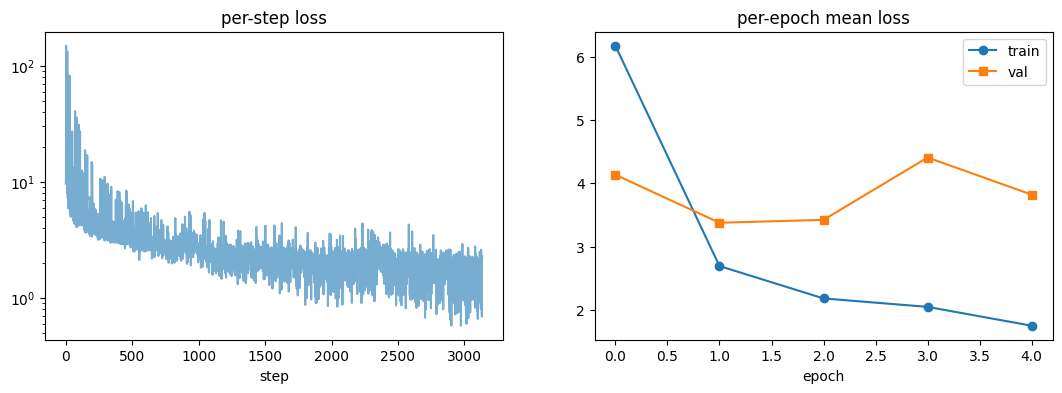

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history["steps"], alpha=0.6)
ax[0].set_yscale("log")
ax[0].set_title("per-step loss")
ax[0].set_xlabel("step")
ax[1].plot(history["train"], "o-", label="train")
ax[1].plot(history["val"], "s-", label="val")
ax[1].set_title("per-epoch mean loss")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.show()

## 7. Test — distance-AP on the held-out log

Center-distance (AV2-style bands): a detection is a TP if its centre lands within 0.5/1/2/4 m of an unmatched GT centre of the same class. Loads the best-val checkpoint first.

In [18]:
model.load_state_dict(torch.load(CKPT, weights_only=True)["model"])
report = evaluate_model(model, val_frames, input_fn=input_fn, device=DEVICE)
print_ap_report(report)
save_report(report,
            RESULTS)  # results/<MODEL>.json — reload in §9 to compare runs

class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.323   0.406   0.447   0.476   0.413  428
PERSON        0.330   0.332   0.337   0.367   0.342  443
TRAFFIC_CONE  —       —       —       —       —      0

F1-optimal operating point @2 m (apply 'confidence >= score' at deployment):
class         prec    recall  F1      score   
----------------------------------------------
VEHICLE       0.584   0.439   0.501   0.239   
PERSON        0.539   0.377   0.444   0.146   
TRAFFIC_CONE  —       —       —       —       

mAP 0.377 | macro P 0.561 R 0.408 F1 0.472 @2 m | mean centre error (TP@2m) 0.413 m | 157 frames


PosixPath('results/pipeline_a_yolo26.json')

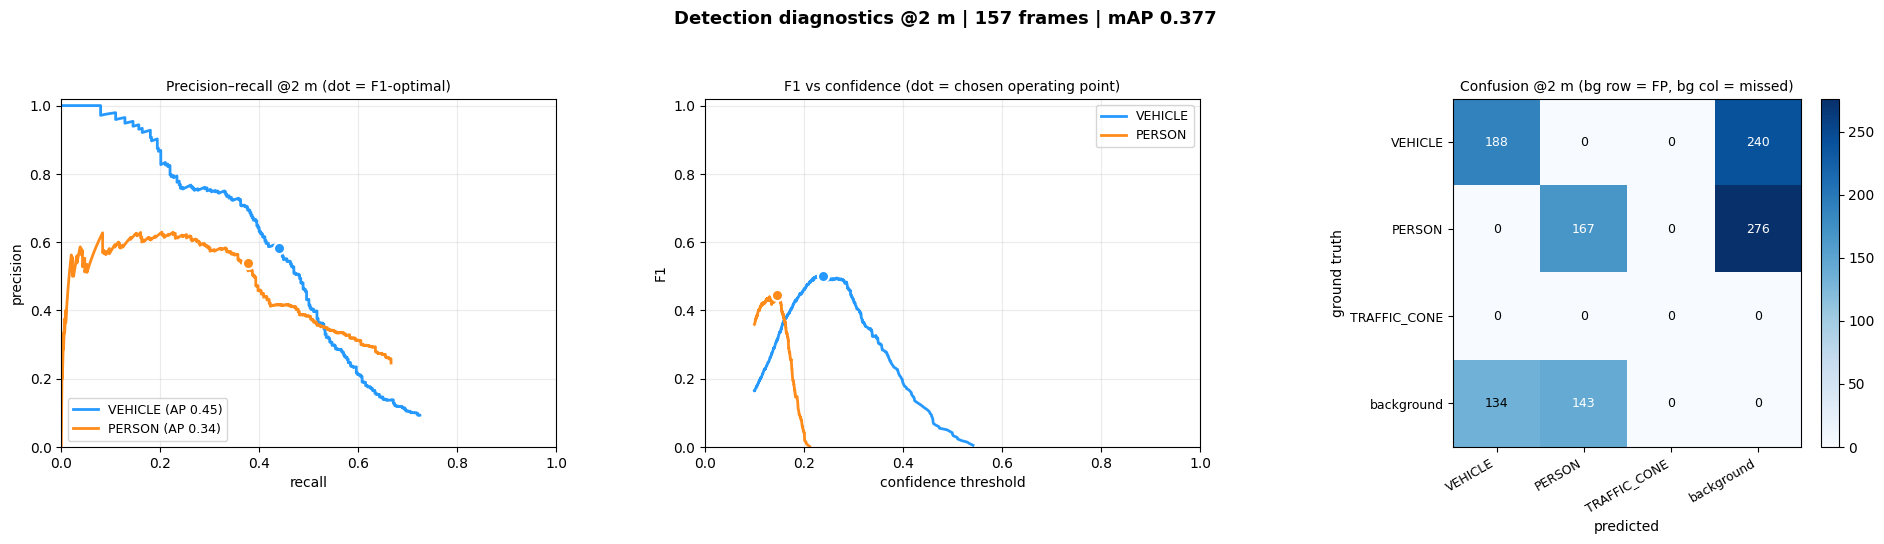

In [24]:
# PR curves + F1-vs-confidence (read the deployment threshold off the peak)
# + confusion matrix (background row = FP, background column = missed GT)
utils.visualize_evaluation(report)

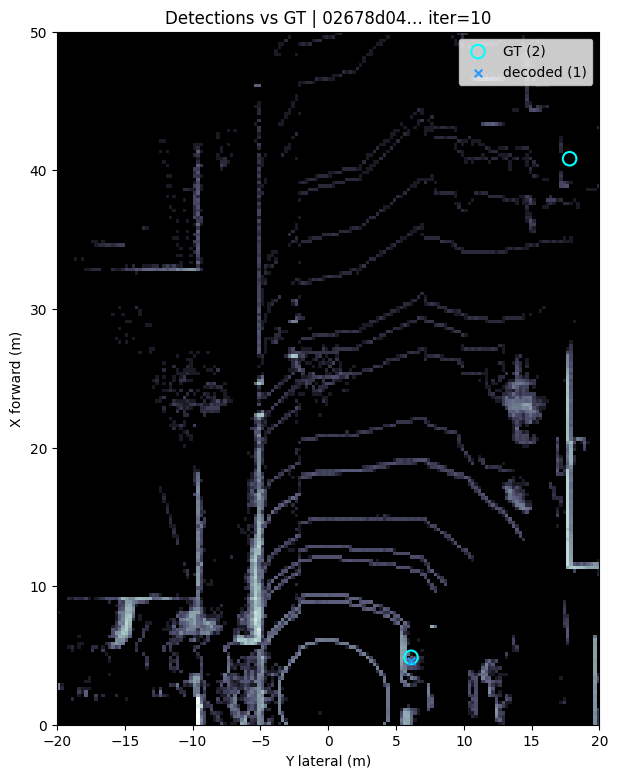

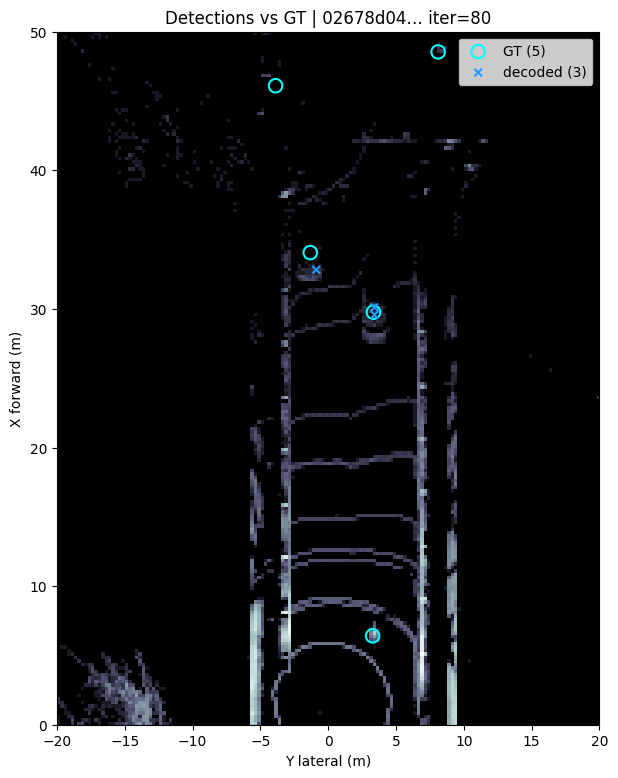

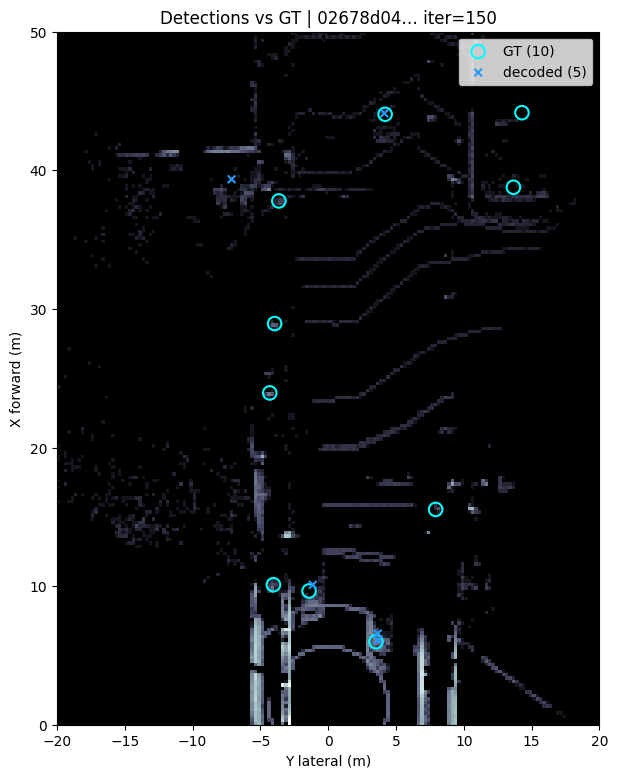

In [20]:
# qualitative check: decoded detections vs GT on a few val frames
model.eval()
decoder = CenterPointDecoder(score_threshold=0.2)
for frame in val_frames[10:151:70]:
    sample = frame.to_stereo_sample()
    with torch.no_grad():
        out = model(input_fn(sample) if input_fn else sample, device=DEVICE)
    det = decoder(out["heatmap"].cpu(), out["offset"].cpu())[0]
    utils.visualize_detections(sample, det)

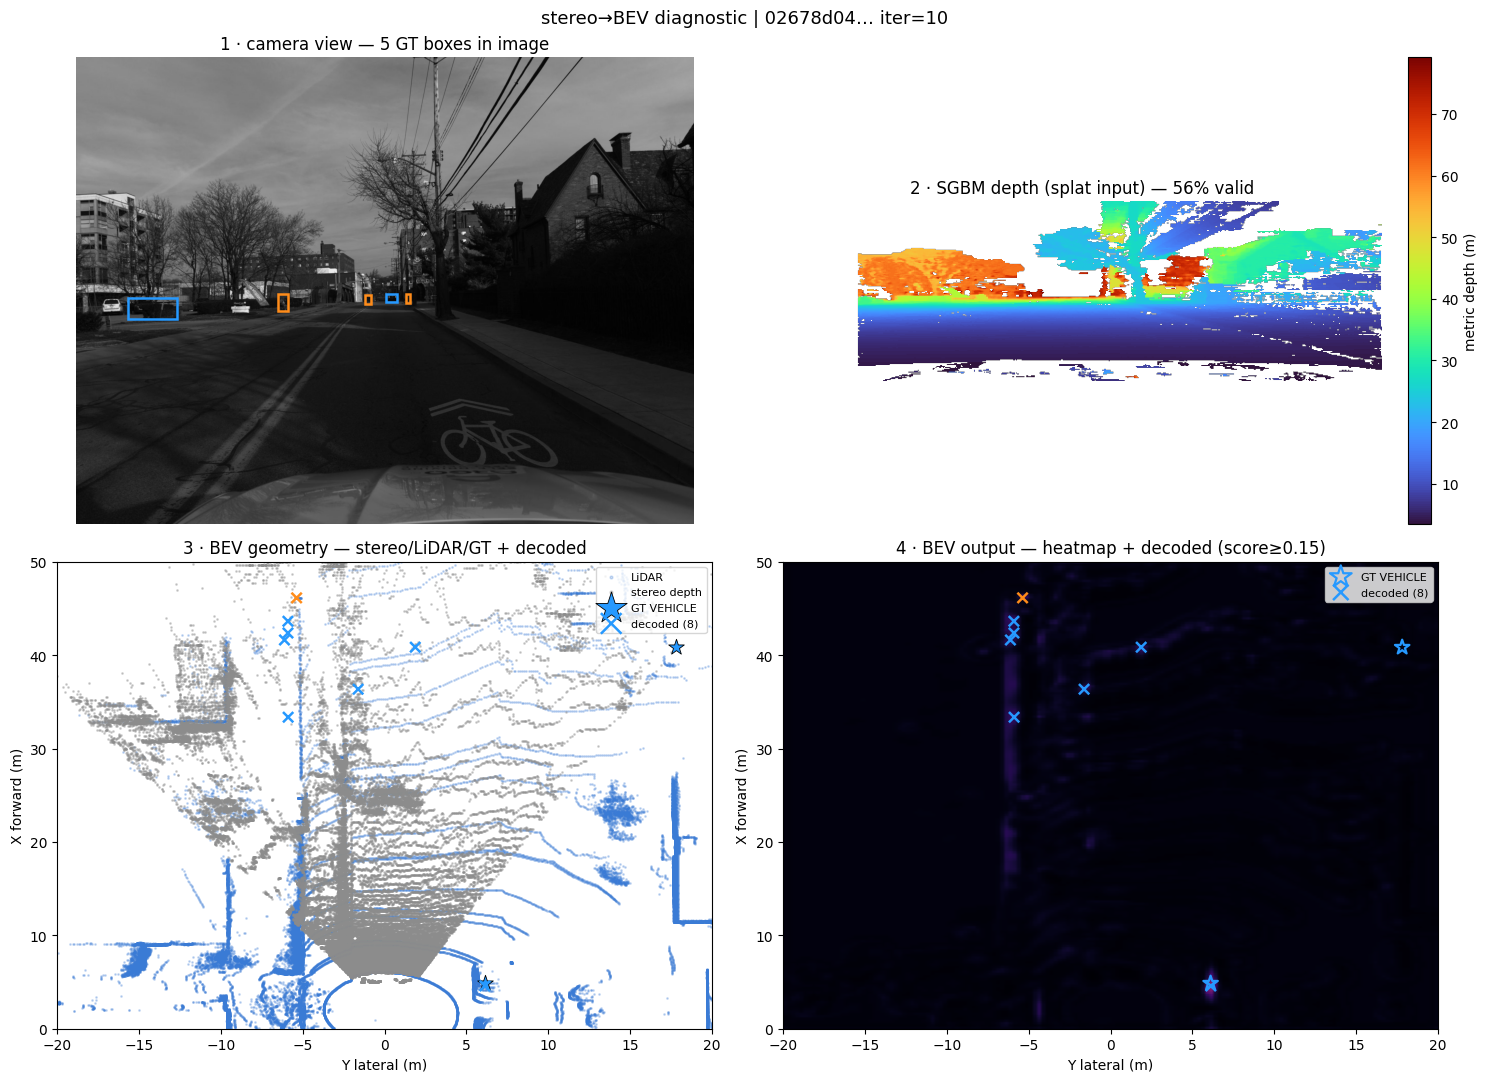

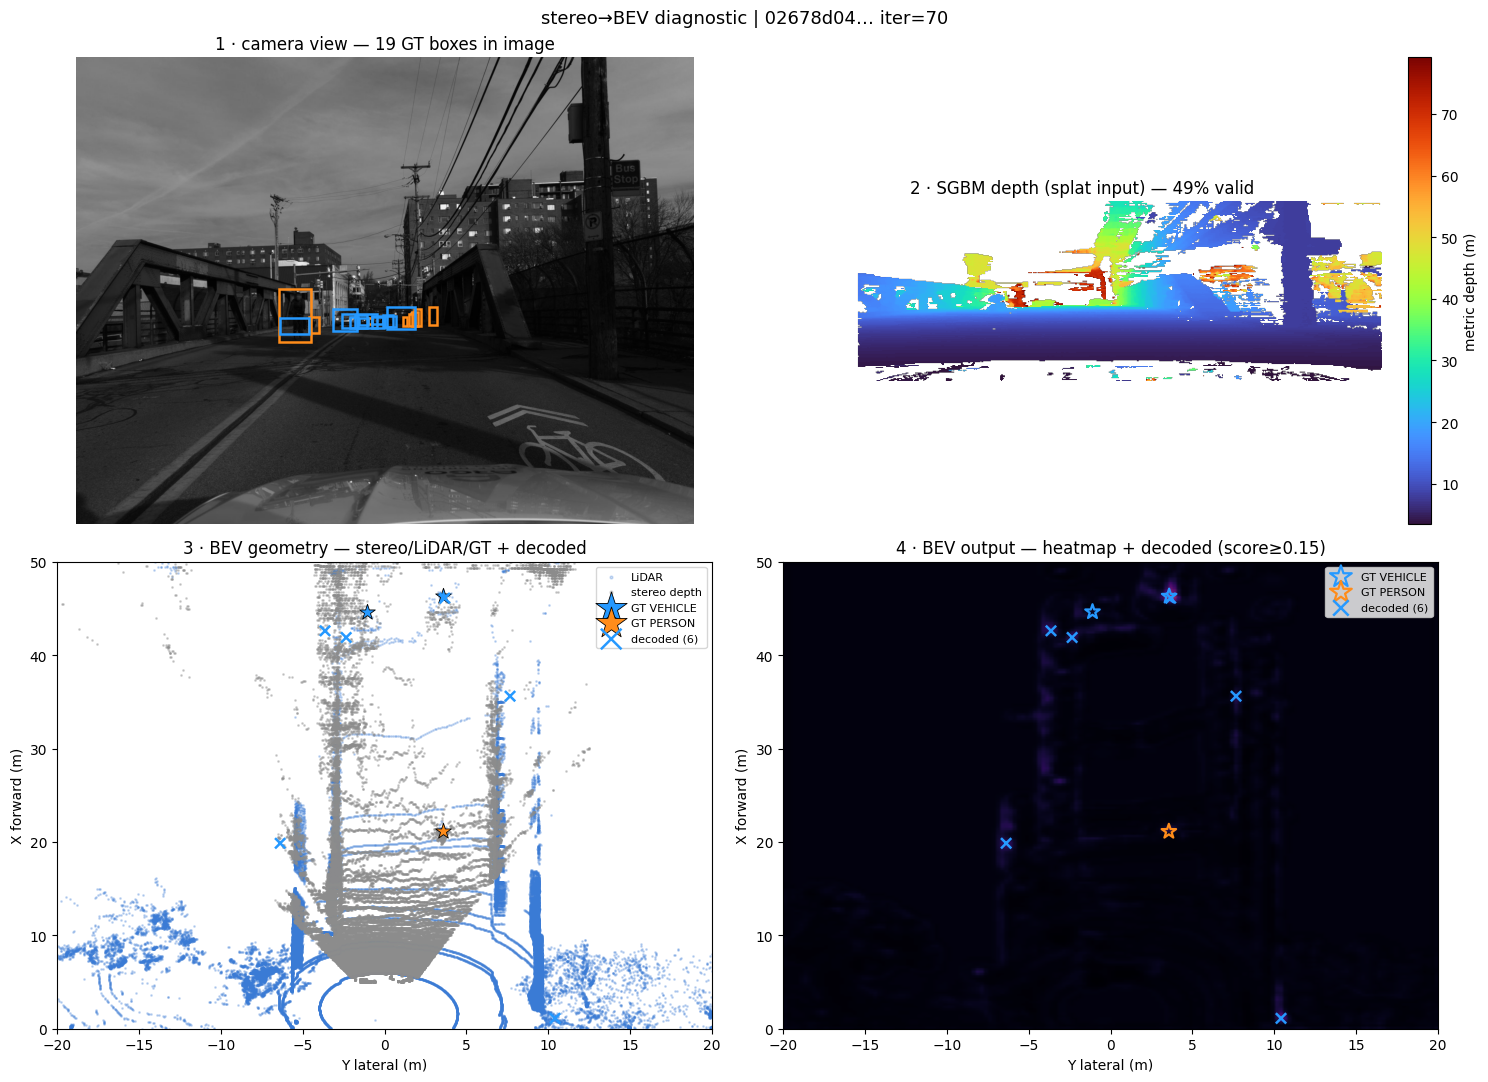

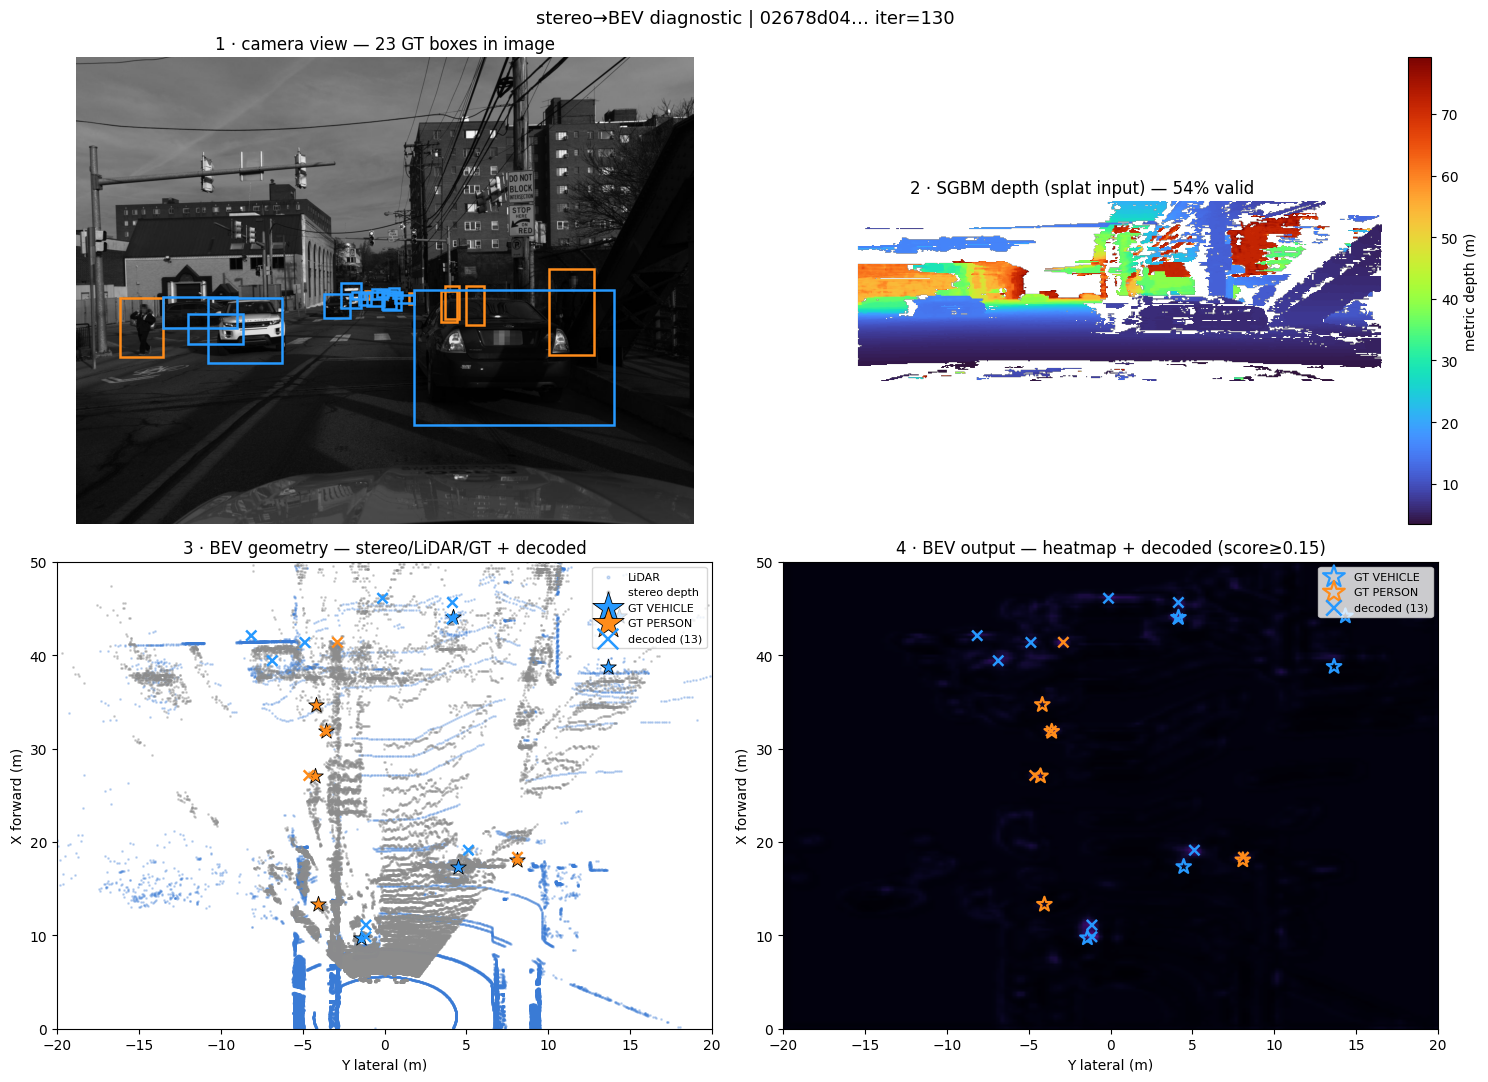

In [23]:
# stereo -> BEV diagnostic: does the net SEE objects (panel 1) but fail to PLACE
# them in BEV because the stereo depth is missing/wrong (panel 3) -> empty output
# (panel 4)? Needs full samples (images). Camera / pipeline_a only.
if MODEL != "lidar":
    for frame in val_frames[10:151:60]:
        sample = frame.to_stereo_sample()  # full sample (load_images=True)
        utils.visualize_stereo_bev_diagnostic(model,
                                              sample,
                                              device=DEVICE,
                                              score_threshold=0.15)
else:
    print("stereo diagnostic is camera/fusion only (needs the stereo branch)")

## 8. Branch contribution (fused runs only)

Two complementary measurements:

1. **Baselines table** — train `lidar`, `camera`, `pipeline_a` with this same notebook (same split/seed/epochs) and compare their AP tables. Fusion's contribution = `pipeline_a` − best single-sensor baseline.
2. **Branch dropout** — evaluate the *trained* fused model with one branch zeroed (`drop_branch`): the AP drop is that branch's marginal contribution inside the fusion. Caveat: a zeroed map is a "silent sensor" the fusion conv never saw in training — it bounds the contribution, it's not a retrained baseline.

In [21]:
if MODEL == "pipeline_a":
    for drop in (None, "camera", "lidar"):
        model.drop_branch = drop
        rep = evaluate_model(model,
                             val_frames,
                             input_fn=input_fn,
                             device=DEVICE)
        print(f"\n=== drop_branch = {drop} "
              f"(mAP {rep['mAP']:.3f}) {'=' * 30}")
        print_ap_report(rep)
    model.drop_branch = None  # always reset
else:
    print(
        "single-sensor run — train MODEL='pipeline_a' for the dropout ablation"
    )


=== drop_branch = None (mAP 0.377) ==============================
class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.323   0.406   0.447   0.476   0.413  428
PERSON        0.330   0.332   0.337   0.367   0.342  443
TRAFFIC_CONE  —       —       —       —       —      0

F1-optimal operating point @2 m (apply 'confidence >= score' at deployment):
class         prec    recall  F1      score   
----------------------------------------------
VEHICLE       0.584   0.439   0.501   0.239   
PERSON        0.539   0.377   0.444   0.146   
TRAFFIC_CONE  —       —       —       —       

mAP 0.377 | macro P 0.561 R 0.408 F1 0.472 @2 m | mean centre error (TP@2m) 0.413 m | 157 frames

=== drop_branch = camera (mAP 0.362) ==============================
class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.294   0.357   0.390   0.417 

## 9. Compare saved approaches

Every §7 run wrote `results/<MODEL>.json`. Load them all back and print one
table — no re-evaluation needed. Run this after you've trained + tested each of
`lidar`, `camera`, `pipeline_a` (same split/seed). The per-class columns are the
mean AP over the 0.5/1/2/4 m thresholds; P/R/F1 are macro at the 2 m operating
point. Fusion's contribution = `pipeline_a` row − best single-sensor row.

In [ ]:
from pathlib import Path

runs = {p.stem: load_report(p) for p in sorted(Path("results").glob("*.json"))}
if runs:
    compare_reports(runs)
else:
    print("no saved reports yet — run §7 for each MODEL first")

## Next

- Run all three: `MODEL = "lidar"` → `"camera"` → `"pipeline_a"` (same split/seed) and build the baselines-vs-fusion AP table; then the §8 dropout ablation on the fused checkpoint.
- More data: download more KITTI-360 sequences via `scripts/get_kitti360.sh` (e.g. `TRAIN_SEQ="0000 0002 0004"`); urban drives add PERSON/TWO_WHEELER support. Keep drive_0010 (`kitti360_val`) purely for eval.
- BEV augmentation (rotation/flip), warm-start the fused run from the baselines, per-range AP bins, and the full CDS metric.